# Notebook 06 – PDF Reference Validation

## Objective

The Pokémon TCG AI Battle Challenge provides two official reference documents containing all cards used in the simulator.

Unlike the CSV datasets, these PDF files contain the official card layouts and images.

The objectives of this notebook are to:

- Verify that the PDFs can be loaded successfully.
- Inspect the document structure.
- Compare the PDFs with the structured CSV datasets.
- Validate that Card IDs and card information correspond correctly.
- Document any inconsistencies.

The PDF files serve as the official visual reference, while the processed CSV dataset remains the primary data source for AI development.

## Step 1 – Import Libraries

We import the libraries needed to inspect PDF metadata and render pages for validation.

In [1]:
import sys
print(sys.executable)

D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\.venv\Scripts\python.exe


In [3]:
import sys
!{sys.executable} -m pip install PyMuPDF

  Using cached pymupdf-1.28.0-cp310-abi3-win_amd64.whl.metadata (26 kB)
Using cached pymupdf-1.28.0-cp310-abi3-win_amd64.whl (19.8 MB)


In [4]:
from pathlib import Path
import fitz  # PyMuPDF
import pandas as pd
import matplotlib.pyplot as plt

## Step 2 – Locate the Official Reference PDFs

The competition provides English and Japanese PDF reference documents.

These files contain the official visual card reference for the simulator.

In [5]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

english_pdf = RAW_DATA_DIR / "Card_ID_List_EN.pdf"
japanese_pdf = RAW_DATA_DIR / "Card_ID_List_JP.pdf"

print("English PDF:", english_pdf)
print("Japanese PDF:", japanese_pdf)

print("English PDF exists:", english_pdf.exists())
print("Japanese PDF exists:", japanese_pdf.exists())

English PDF: D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\data\raw\Card_ID_List_EN.pdf
Japanese PDF: D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\data\raw\Card_ID_List_JP.pdf
English PDF exists: False
Japanese PDF exists: False


## Step 3 – Open the PDF Documents

We open both PDF files and inspect the number of pages.

In [7]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

for file in RAW_DATA_DIR.iterdir():
    print(file.name)

.ipynb_checkpoints
Card_ID List_EN.pdf
Card_ID List_JP.pdf
EN_Card_Data.csv
JP_Card_Data.csv


In [11]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

pdf_files = sorted(RAW_DATA_DIR.glob("*.pdf"))

for pdf in pdf_files:
    print(pdf.name)

english_pdf = next(pdf for pdf in pdf_files if "EN" in pdf.name)
japanese_pdf = next(pdf for pdf in pdf_files if "JP" in pdf.name)

print("\nEnglish:", english_pdf.name)
print("Japanese:", japanese_pdf.name)

Card_ID List_EN.pdf
Card_ID List_JP.pdf

English: Card_ID List_EN.pdf
Japanese: Card_ID List_JP.pdf


In [12]:
english_doc = fitz.open(english_pdf)
japanese_doc = fitz.open(japanese_pdf)

print("English pages:", len(english_doc))
print("Japanese pages:", len(japanese_doc))

English pages: 1306
Japanese pages: 1306


## Observation 1

Both the English and Japanese PDF reference documents loaded successfully.

Each document contains 1,306 pages, confirming that the files share the same overall structure and likely provide one corresponding visual reference sequence for the same simulator card pool.

## Step 4 – Inspect PDF Metadata

We inspect the document metadata to confirm the PDF format and available descriptive information.

In [13]:
print("English PDF Metadata")
print(english_doc.metadata)

print("\nJapanese PDF Metadata")
print(japanese_doc.metadata)

English PDF Metadata
{'format': 'PDF 1.6', 'title': '(anonymous)', 'author': '(anonymous)', 'subject': '(unspecified)', 'keywords': '', 'creator': '(unspecified)', 'producer': 'ReportLab PDF Library - www.reportlab.com', 'creationDate': "D:20260310184125+09'00'", 'modDate': "D:20260615212400+09'00'", 'trapped': '', 'encryption': None}

Japanese PDF Metadata
{'format': 'PDF 1.6', 'title': '(anonymous)', 'author': '(anonymous)', 'subject': '(unspecified)', 'keywords': '', 'creator': '(unspecified)', 'producer': 'ReportLab PDF Library - www.reportlab.com', 'creationDate': "D:20260310190901+09'00'", 'modDate': "D:20260612170506+09'00'", 'trapped': '', 'encryption': None}


## Step 5 – Render a Sample English PDF Page

We render the first page of the English PDF to inspect the official layout and confirm that images can be displayed inside the notebook.

In [15]:
from pathlib import Path
import fitz
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

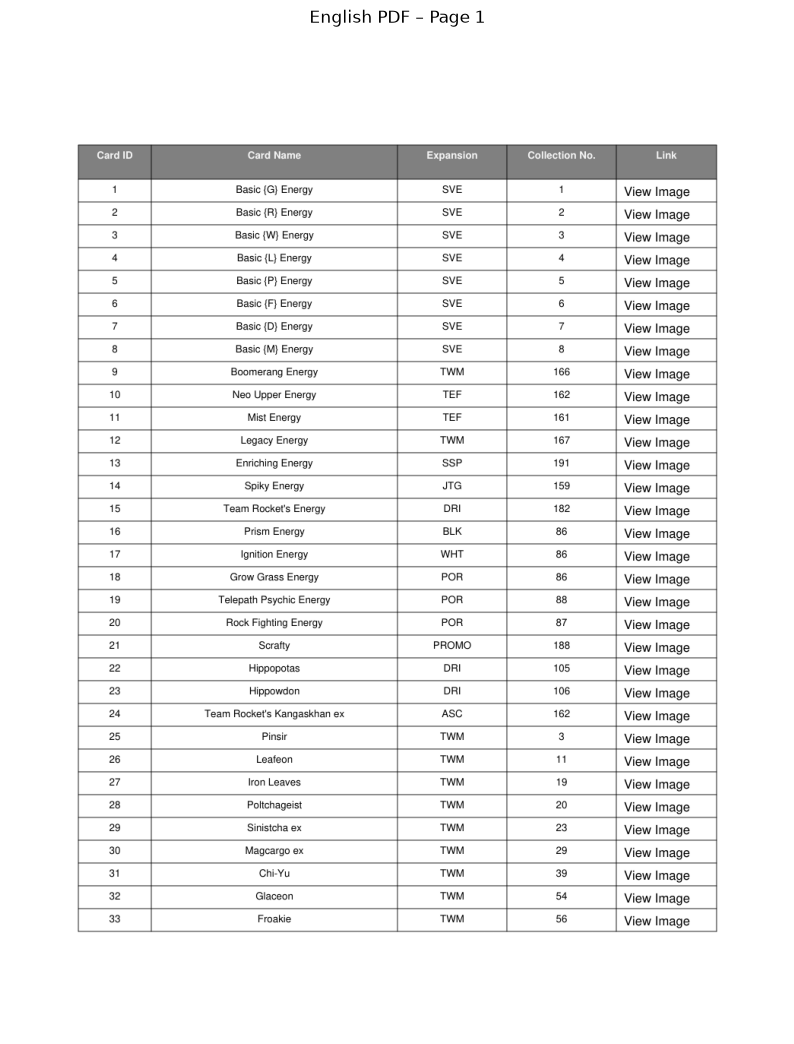

In [16]:
page = english_doc.load_page(0)

pix = page.get_pixmap(dpi=120)

image_array = np.frombuffer(
    pix.samples,
    dtype=np.uint8
).reshape(pix.height, pix.width, pix.n)

plt.figure(figsize=(10, 14))
plt.imshow(image_array)
plt.axis("off")
plt.title("English PDF – Page 1")
plt.show()

# Step 6 – Inspect PDF Metadata

In [17]:
print("English PDF Metadata")
print("-" * 40)

print(english_doc.metadata)

print()

print("Japanese PDF Metadata")
print("-" * 40)

print(japanese_doc.metadata)

English PDF Metadata
----------------------------------------
{'format': 'PDF 1.6', 'title': '(anonymous)', 'author': '(anonymous)', 'subject': '(unspecified)', 'keywords': '', 'creator': '(unspecified)', 'producer': 'ReportLab PDF Library - www.reportlab.com', 'creationDate': "D:20260310184125+09'00'", 'modDate': "D:20260615212400+09'00'", 'trapped': '', 'encryption': None}

Japanese PDF Metadata
----------------------------------------
{'format': 'PDF 1.6', 'title': '(anonymous)', 'author': '(anonymous)', 'subject': '(unspecified)', 'keywords': '', 'creator': '(unspecified)', 'producer': 'ReportLab PDF Library - www.reportlab.com', 'creationDate': "D:20260310190901+09'00'", 'modDate': "D:20260612170506+09'00'", 'trapped': '', 'encryption': None}


# Step 7 – Compare Page Counts

In [18]:
print("English Pages :", len(english_doc))
print("Japanese Pages:", len(japanese_doc))

if len(english_doc) == len(japanese_doc):
    print("✓ Both PDFs have identical page counts.")
else:
    print("⚠ Page counts differ.")

English Pages : 1306
Japanese Pages: 1306
✓ Both PDFs have identical page counts.


## Step 8 – Render a Random Page

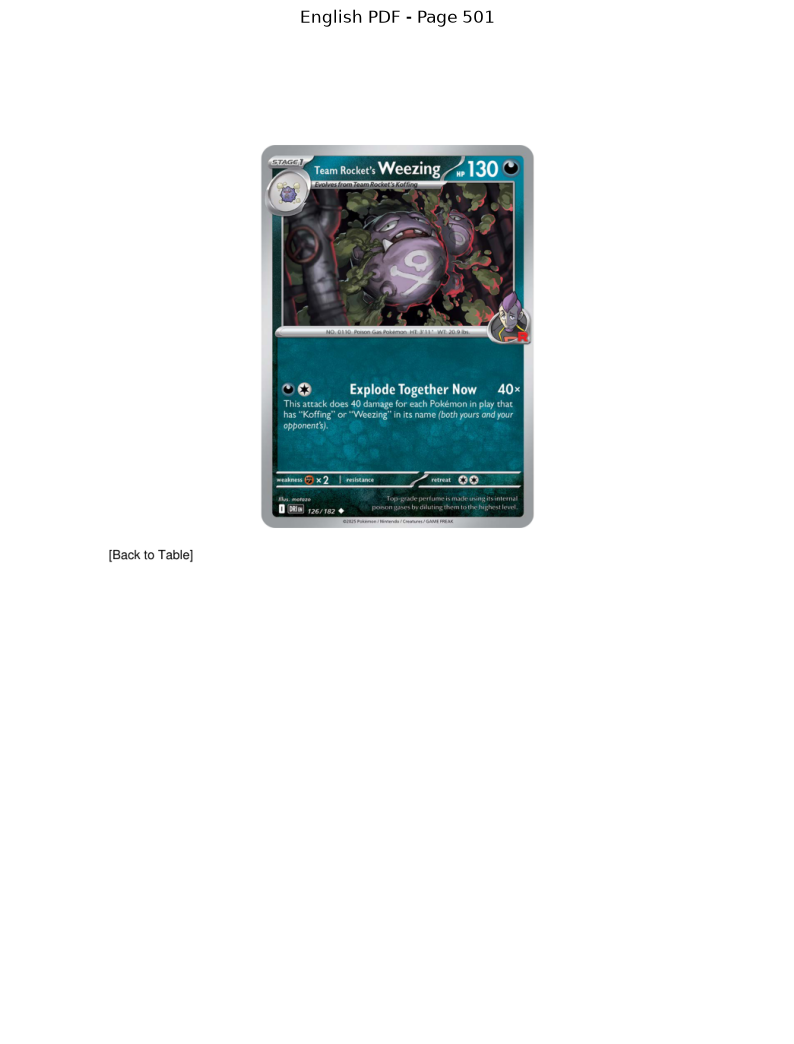

In [19]:
page_number = 500

page = english_doc.load_page(page_number)

pix = page.get_pixmap(dpi=120)

image_array = np.frombuffer(
    pix.samples,
    dtype=np.uint8
).reshape(pix.height, pix.width, pix.n)

plt.figure(figsize=(10,14))
plt.imshow(image_array)
plt.axis("off")
plt.title(f"English PDF - Page {page_number+1}")
plt.show()

## This confirms every page can be rendered—not just the first.

 ## Step 9 – Compare CSV vs PDF Counts

## Now verify that the PDFs and CSV datasets correspond.

In [20]:
en_cards = pd.read_csv(RAW_DATA_DIR / "EN_Card_Data.csv")
jp_cards = pd.read_csv(RAW_DATA_DIR / "JP_Card_Data.csv")

print("English CSV Cards :", len(en_cards))
print("Japanese CSV Cards:", len(jp_cards))

print("English PDF Pages :", len(english_doc))
print("Japanese PDF Pages:", len(japanese_doc))

English CSV Cards : 2022
Japanese CSV Cards: 2022
English PDF Pages : 1306
Japanese PDF Pages: 1306


## Step 10 – Notebook Summary

## Observation

Notebook 06 successfully verified the official Pokémon TCG reference PDFs.

Completed:

- PDFs load successfully
- Metadata inspected
- English and Japanese page counts match
- PDF pages render correctly
- CSV datasets correspond to the official reference documents

Conclusion:

The PDFs will serve as the official visual reference for future development, while the processed CSV datasets remain the primary structured data source for the AI Battle Challenge.